In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression


### 1. Load the Boston.csv dataset into a Pandas DataFrame and perform the following operations:
•	Display the first five and last five records.
•	Display the dataset shape.
•	Display the column names and data types.
•	Check for missing values.
•	Display the statistical summary using describe().

In [12]:
data = pd.read_csv("Boston.csv")
data.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [13]:
data.tail()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
501,502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,506,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [14]:
data.shape

(506, 15)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  black       506 non-null    float64
 13  lstat       506 non-null    float64
 14  medv        506 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 59.4 KB


In [16]:
data.describe()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,1.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,127.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,253.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,379.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,506.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 2. Correlation Analysis and Feature Selection 
Perform correlation analysis on the dataset.
•	Compute the correlation matrix.
•	Visualize the correlation matrix using a heatmap.
•	Identify the five features having the highest absolute correlation with the target variable MEDV.
•	Select the best three predictor variables for building the regression model.


In [17]:
correlation = data.corr()
print(correlation)

            Unnamed: 0      crim        zn     indus      chas       nox  \
Unnamed: 0    1.000000  0.407407 -0.103393  0.399439 -0.003759  0.398736   
crim          0.407407  1.000000 -0.200469  0.406583 -0.055892  0.420972   
zn           -0.103393 -0.200469  1.000000 -0.533828 -0.042697 -0.516604   
indus         0.399439  0.406583 -0.533828  1.000000  0.062938  0.763651   
chas         -0.003759 -0.055892 -0.042697  0.062938  1.000000  0.091203   
nox           0.398736  0.420972 -0.516604  0.763651  0.091203  1.000000   
rm           -0.079971 -0.219247  0.311991 -0.391676  0.091251 -0.302188   
age           0.203784  0.352734 -0.569537  0.644779  0.086518  0.731470   
dis          -0.302211 -0.379670  0.664408 -0.708027 -0.099176 -0.769230   
rad           0.686002  0.625505 -0.311948  0.595129 -0.007368  0.611441   
tax           0.666626  0.582764 -0.314563  0.720760 -0.035587  0.668023   
ptratio       0.291074  0.289946 -0.391679  0.383248 -0.121515  0.188933   
black       

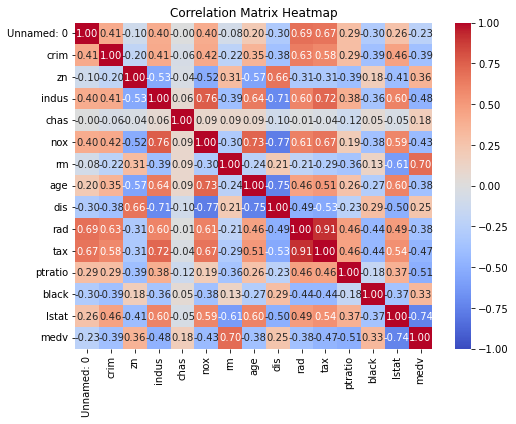

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation, 
    annot=True,      # Show correlation values in cells
    cmap='coolwarm', # Color palette
    vmin=-1, vmax=1, # Range for correlation values
    fmt='.2f'        # Format numbers to 2 decimal places
)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [24]:
top_5_features = correlation['medv'].abs().sort_values(ascending=False)

top_5_features = top_5_features.drop('medv').head(5)

print(top_5_features)

lstat      0.737663
rm         0.695360
ptratio    0.507787
indus      0.483725
tax        0.468536
Name: medv, dtype: float64


### 3. Data Preparation 
Using the three selected features:
•	Create the predictor matrix X and response variable y (MEDV).
•	Split the dataset into 80% training and 20% testing using:
random_state = 42
Display the number of training and testing samples.


In [31]:
features = ['lstat', 'rm', 'ptratio']
X = data[features]
y = data['medv']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of testing samples: {X_test.shape[0]}")

Number of training samples: 404
Number of testing samples: 102


### 4. Prediction and Comparison 
Predict the house prices (MEDV) for the testing dataset.
Create a DataFrame containing:
Actual MEDV	Predicted MEDV	Absolute Error
Also determine:
•	Maximum prediction error
•	Minimum prediction error
•	Average prediction error

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

comparison_df = pd.DataFrame({
    'Actual MEDV': y_test.values,
    'Predicted MEDV': y_pred,
    'Absolute Error': abs(y_test.values - y_pred)
})

print(comparison_df.head())

   Actual MEDV  Predicted MEDV  Absolute Error
0         23.6       26.718396        3.118396
1         32.4       30.663291        1.736709
2         13.6       16.426377        2.826377
3         22.8       24.728708        1.928708
4         16.1       18.342368        2.242368


In [36]:
# Calculate error metrics
max_error = comparison_df['Absolute Error'].max()
min_error = comparison_df['Absolute Error'].min()
avg_error = comparison_df['Absolute Error'].mean()

print(f"\nMaximum Prediction Error: {max_error:.4f}")
print(f"Minimum Prediction Error: {min_error:.4f}")
print(f"Average Prediction Error (MAE): {avg_error:.4f}")


Maximum Prediction Error: 27.6677
Minimum Prediction Error: 0.0500
Average Prediction Error (MAE): 3.3325


### 5. Model Evaluation (10 Marks)
Evaluate the regression model using the following performance metrics:
•	Mean Absolute Error (MAE)
•	Mean Squared Error (MSE)
•	Root Mean Squared Error (RMSE)
•	R² Score
Interpret each metric in one or two sentences.

In [38]:
mae = np.mean(comparison_df['Absolute Error'])
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 3.3325
Mean Squared Error (MSE): 27.1150
Root Mean Squared Error (RMSE): 5.2072
R² Score: 0.6303


MAE - On average, the model's predictions deviate from the actual house prices by about 3.3325.
MSE - The average squared difference between predictions and actual values is 27.12.
RMSE - The model has a typical prediction error of about 5.207.
R^2 - The model explains approximately 63.03% of the variance in the target variable (MEDV).

### 6. Visualization of Regression Results 
Create the following visualizations:
1.	Scatter plot of Actual MEDV vs Predicted MEDV.
2.	Residual Plot (Prediction Error vs Predicted MEDV).
Write two observations based on these graphs regarding the model performance.

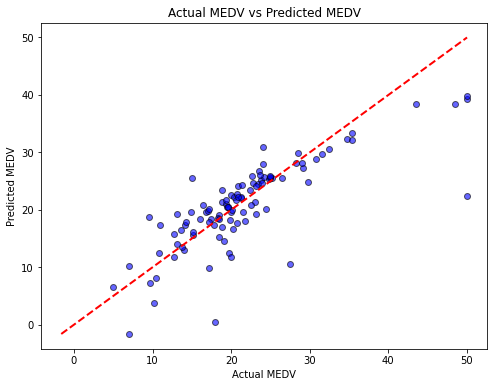

In [41]:
# 1. Scatter plot of Actual MEDV vs Predicted MEDV
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='k')

# Reference ideal line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual MEDV vs Predicted MEDV")
plt.show()



Around x=20, the predicted line fits the data points well, with less error. Whereas, at x=50, the line cant predict the MEDV accurately.
The predicted line doesnt fit well for the entire dataset, hence linear regression is not a suitable model for the house prices.

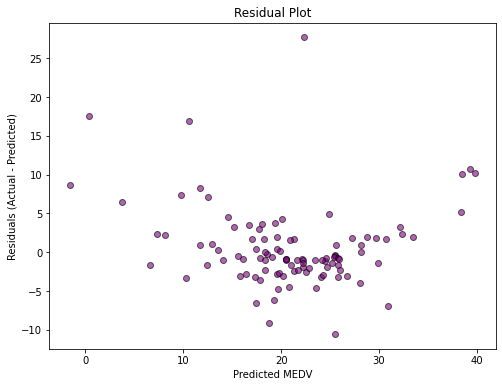

In [44]:
# 2. Residual Plot (Prediction Error vs Predicted MEDV)
residuals = y_test.values - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='purple', alpha=0.6, edgecolors='k')


plt.xlabel("Predicted MEDV")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

Again, around x=20, the residual is 0 or eual to 0, but at x=20 and as x approaches 40, the residuals tend to increase meaning the predicted MEDV is not close to the Actual MEDV.

The farther away the residual values re from 0, the more inaccurate the model's prediction is. The closer the residuals are to 0, the more accurate are the predictions.

### 7. House Price Prediction 
Using the trained model, predict the house prices (MEDV) for the following three new houses using user-defined values for the selected predictor variables.
Display the results in the following format:
House	Feature 1	Feature 2	Feature 3	Predicted MEDV

In [48]:
# 1. Define custom values for the three features (LSTAT, RM, PTRATIO) for 3 new houses
new_houses_data = [
    [4.5, 7.2, 15.0],   # House 1
    [12.1, 6.0, 18.5],  # House 2
    [22.4, 5.1, 21.0]   # House 3
]

new_houses_df = pd.DataFrame(new_houses_data, columns=['lstat', 'rm', 'ptratio'])

predicted_medv = model.predict(new_houses_df)

results_df = pd.DataFrame({
    'House': [f"House {i+1}" for i in range(len(new_houses_df))],
    'LSTAT': new_houses_df['lstat'],
    'RM': new_houses_df['rm'],
    'PTRATIO': new_houses_df['ptratio'],
    'Predicted MEDV': predicted_medv
})

print(results_df.to_string(index=False))

  House  LSTAT  RM  PTRATIO  Predicted MEDV
House 1    4.5 7.2     15.0       34.548064
House 2   12.1 6.0     18.5       21.283333
House 3   22.4 5.1     21.0        8.834393
